In [11]:
import numpy as np; 
import matplotlib.pyplot as plt; 
#%matplotlib inline

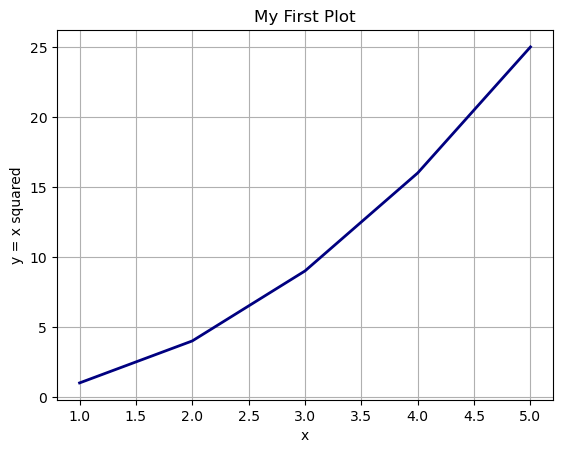

In [20]:
import matplotlib.pyplot as plt; 
x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]
plt.plot(x, y, color='navy', linewidth=2)
plt.title("My First Plot")
plt.xlabel('x')
plt.xlabel('x')
plt.ylabel('y = x squared')
plt.grid(True)
plt.show()

In [31]:
v = np.array([1, 2, 3]) # Shape (3,) — ambiguous: row or column?
row = v.reshape(1, 3) # Shape (1, 3) — explicitly a row vector
col = v.reshape(3, 1) # Shape (3, 1) — explicitly a column vector
print(row.shape) # (1, 3)
print(col.shape) # (3, 1)
# Shorthand for column vector:
col = v[:, np.newaxis] # Same as reshape(3,1)
row = v[:, np.newaxis]
print(col)
print(row)
# [[1]
# [2]
# [3]

(1, 3)
(3, 1)
[[1]
 [2]
 [3]]
[[1]
 [2]
 [3]]


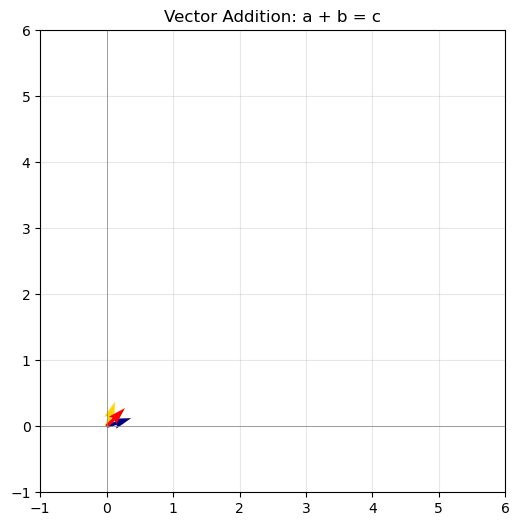

In [55]:
a = np.array([3, 1])
b = np.array([1, 3])
c = a + b
fig, ax = plt.subplots(figsize =(6, 6))
ax.quiver(0, 0, a[0], a[1], angles = 'xy', scale_units = 'xy', color = 'navy', label = 'a = [3, 1]')
ax.quiver(0, 0, b[0], b[1], angles = 'xy', scale_units = 'xy', color = 'gold', label = 'b = [1, 3]')
ax.quiver(0, 0, c[0], c[1], angles = 'xy', scale_units = 'xy', color = 'red', label = 'a+b = [4, 4]', linestyle='dashed')
ax.set_xlim(-1, 6)
ax.set_ylim(-1, 6)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.grid(True, alpha=0.3)
#ax.legend(fontsize=12)
ax.set_title('Vector Addition: a + b = c')
plt.show()

In [68]:
a = np.array([1, 2, 3])
b = np.array([4, 3])
unit_v = b / np.linalg.norm(v)
print((np.linalg.norm(b)))
print(np.linalg.norm(unit_v))

5.0
1.336306209562122


In [72]:
A = np.array([
[1, 2, 3, 4], # Row 0
[5, 6, 7, 8], # Row 1
[9, 10, 11, 12] # Row 2
]) 
print(A[2, -1])

12


In [81]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Set random seed for reproducibility
np.random.seed(42)

# Create NORMAL data (400 samples, 3 features)
x_normal = np.column_stack([
    np.random.normal(72, 6, 400),   # Feature 1: temperature?
    np.random.normal(3.5, 1, 400),  # Feature 2: vibration?
    np.random.normal(195, 8, 400)   # Feature 3: pressure?
])

# Create FAULT data (100 samples, 3 features)
x_fault = np.column_stack([
    np.random.normal(85, 5, 100),   # Feature 1: higher temp
    np.random.normal(7.8, 1.2, 100), # Feature 2: higher vibration
    np.random.normal(220, 6, 100)    # Feature 3: higher pressure
])

# Combine normal and fault data into ONE feature matrix
x = np.vstack([x_normal, x_fault])  # Stack rows: 400 normal + 100 fault = 500 total

# Create target labels (0 = NORMAL, 1 = FAULT)
y_normal = np.zeros(400)  # 400 zeros for normal
y_fault = np.ones(100)    # 100 ones for fault
y = np.hstack([y_normal, y_fault])  # Combine: 500 labels

print(f"Total samples: {x.shape[0]}")
print(f"Features per sample: {x.shape[1]}")
print(f"Normal samples: {sum(y == 0)}")
print(f"Fault samples: {sum(y == 1)}")

# Split data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (StandardScaler - CORRECTED spelling)
scaler = StandardScaler()  # Was 'standardScaler()' - Python is case-sensitive!
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Define models dictionary (all typos fixed)
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced'),  # Was 'LogisticsRegression'
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
    'K-NN (K=5)': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)  # Was 'n_estimator'
}

# Train and evaluate each model
for name, model in models.items():  # Was 'modeks.items()'
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    print(f"\n{'='*50}")
    print(f"{name}")
    print('='*50)
    print(classification_report(y_test, y_pred, target_names=['NORMAL', 'FAULT']))  # Was 'target_name'
    
    # Optional: Show confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"              Predicted")
    print(f"              NORMAL  FAULT")
    print(f"Actual NORMAL   {cm[0,0]:3}     {cm[0,1]:3}")
    print(f"       FAULT     {cm[1,0]:3}     {cm[1,1]:3}")

Total samples: 500
Features per sample: 3
Normal samples: 400
Fault samples: 100

Logistic Regression
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00        80
       FAULT       1.00      1.00      1.00        20

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


Confusion Matrix:
              Predicted
              NORMAL  FAULT
Actual NORMAL    80       0
       FAULT       0      20

Decision Tree
              precision    recall  f1-score   support

      NORMAL       0.98      0.99      0.98        80
       FAULT       0.95      0.90      0.92        20

    accuracy                           0.97       100
   macro avg       0.96      0.94      0.95       100
weighted avg       0.97      0.97      0.97       100


Confusion Matrix:
              Predicted
              NORMAL  FAULT
Actual NORMAL    79       1
  

[[-0.46326896 -0.21944381  1.45502122  0.00308413 -0.17921047]
 [ 0.0825127  -0.16136437 -0.70957229 -0.99802984 -0.76343134]
 [ 0.87291919 -0.62990525 -0.1549246   0.70073629 -0.27839117]
 [ 0.63336131 -1.54079304 -0.13251668  0.0788961   0.02313872]
 [-1.6529187   1.20311265 -0.85467294  0.33503713  0.00796428]]


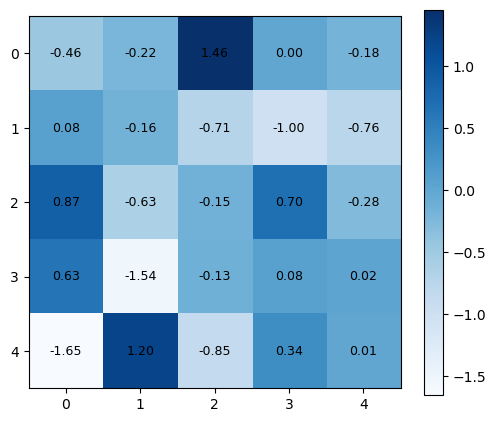

In [120]:
import matplotlib.pyplot as plt
import numpy as np
M = np.random.randn(5, 5)
print(M)
plt.figure(figsize = (6, 5))
plt.imshow(M, cmap = "Blues")
plt.colorbar()
for i in range(5):
    for j in range(5):
        plt.text(j, i, f'{M[i, j]:.2f}', ha = 'center', va = 'center', fontsize = 9)

plt.show()

In [108]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
print(A**2)

[[ 1  4]
 [ 9 16]]


In [121]:
A = np.array([[1, 2, 3],
[4, 5, 6]]) # Shape (2, 3)
B = np.array([[7, 8],
[9, 10],
[11, 12]]) # Shape (3, 2)
print(A@B)
print(np.dot(A, B))
print(np.matmul(A, B))

[[ 58  64]
 [139 154]]
[[ 58  64]
 [139 154]]
[[ 58  64]
 [139 154]]


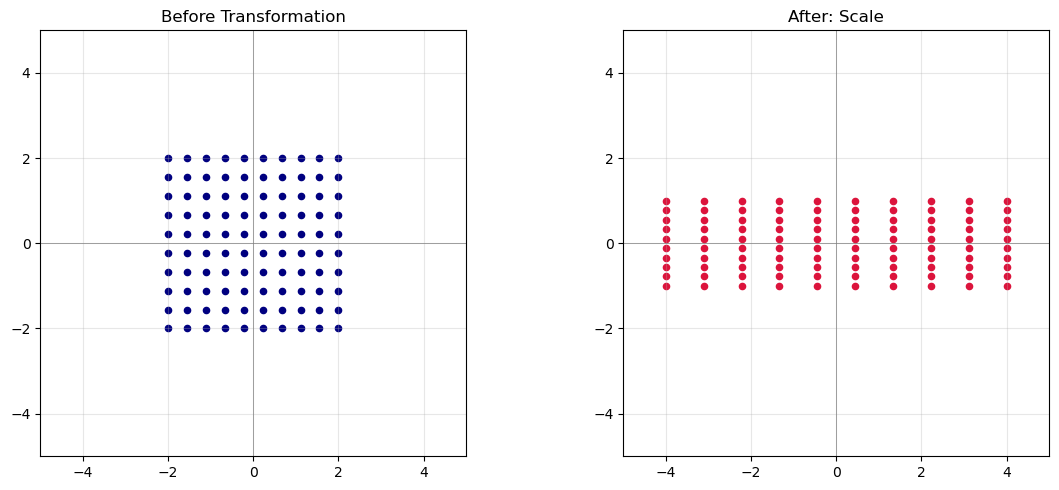

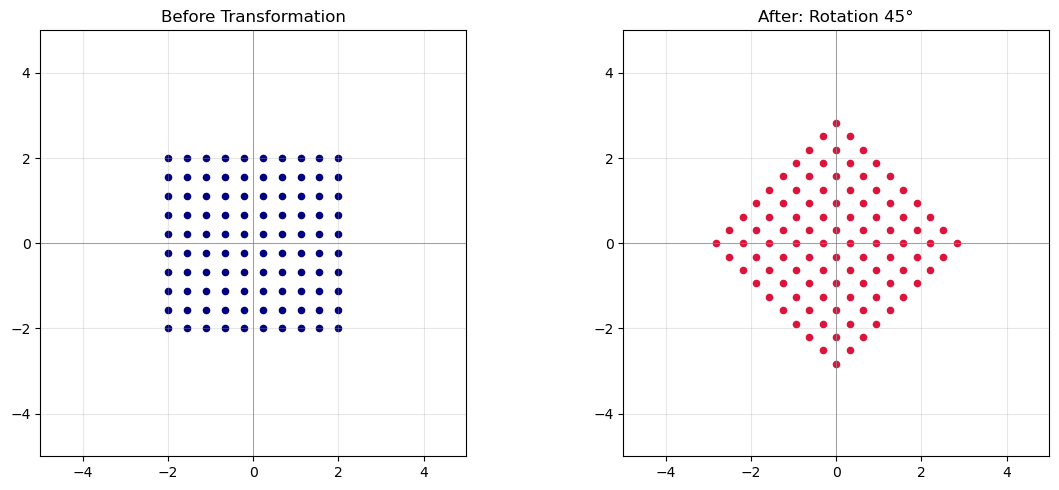

In [134]:
import numpy as np
import matplotlib.pyplot as plt
def plot_transformation(A, title=''):
    # Create a grid of points
    xs = np.linspace(-2, 2, 10)
    ys = np.linspace(-2, 2, 10)
    points = []
    for x in xs:
        for y in ys:
            points.append([x, y])
    points = np.array(points).T # shape (2, N)
    # Apply transformation
    transformed = A @ points
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.scatter(points[0], points[1], color='navy', s=20)
    ax1.set_title('Before Transformation')
    ax1.set_xlim(-5, 5); ax1.set_ylim(-5, 5)
    ax1.axhline(0, color='gray', lw=0.5)
    ax1.axvline(0, color='gray', lw=0.5)
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    ax2.scatter(transformed[0], transformed[1], color='crimson', s=20)
    ax2.set_title(f'After: {title}')
    ax2.set_xlim(-5, 5); ax2.set_ylim(-5, 5)
    ax2.axhline(0, color='gray', lw=0.5)
    ax2.axvline(0, color='gray', lw=0.5)
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal')
    plt.tight_layout()
    plt.show()
# Scale x by 2, y by 0.5
A = np.array([[2, 0], [0, 0.5]])
plot_transformation(A, 'Scale')
# Rotation by 45 degrees
theta = np.pi / 4
R = np.array([[np.cos(theta), -np.sin(theta)],
[np.sin(theta), np.cos(theta)]])
plot_transformation(R, 'Rotation 45°')

In [135]:
I = np.eye(3)
print(I)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


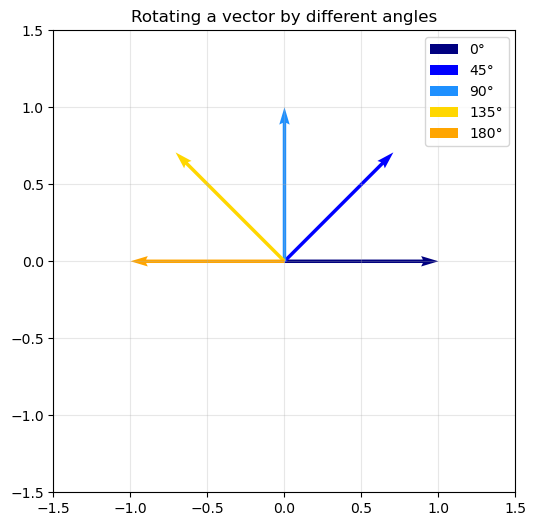

In [143]:
import numpy as np
import matplotlib.pyplot as plt
def rotation_matrix(angle_degrees):
    theta = np.radians(angle_degrees) # convert degrees to radians
    return np.array([[np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]])
v = np.array([1, 0]) # Vector pointing right
fig, ax = plt.subplots(figsize=(6, 6))
colors = ['navy', 'blue', 'dodgerblue', 'gold', 'orange']
for i, angle in enumerate([0, 45, 90, 135, 180]):
    R = rotation_matrix(angle)
    rotated = R @ v
    ax.quiver(0, 0, rotated[0], rotated[1],
    angles='xy', scale_units='xy', scale=1,
    color=colors[i], label=f'{angle}°')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title('Rotating a vector by different angles')
plt.show()

In [144]:
I = np.eye(2)
v = np.array([5, -2, 7])
print(I @ v) # [5. -2. 7.] — unchanged
# The identity matrix is the number '1' for matrices.
# A @ I = A and I @ A = A for any matrix 

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 2)

In [156]:
A = np.array([
    [3, 1],
    [0, 2]
])
eigenvalues, eigenvectors = np.linalg.eig(A)
print("EIgenvalues: ", eigenvalues)
print('Eigenvectors (columns):',)
print(eigenvectors)
# Verify: A @ v = lambda * v for the first eigenpair
v0 = eigenvectors[:, 0] # First eigenvector
lam0 = eigenvalues[0] # First eigenvalue
print(np.allclose(A @ v0, lam0 * v0)) # True ✓

EIgenvalues:  [3. 2.]
Eigenvectors (columns):
[[ 1.         -0.70710678]
 [ 0.          0.70710678]]
True


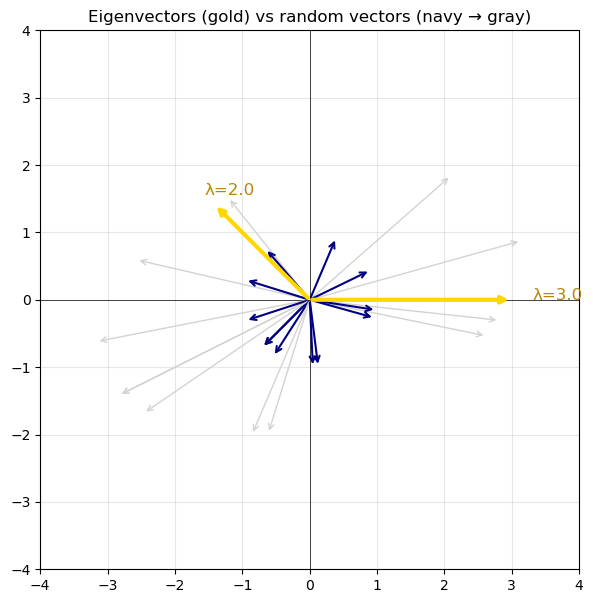

In [160]:
A = np.array([[3., 1.],
              [0., 2.]])
vals, vecs = np.linalg.eig(A)
fig, ax = plt.subplots(figsize=(7, 7))
# Show effect on random vectors
np.random.seed(42)
for _ in range(12):
    v = np.random.randn(2)
    v = v / np.linalg.norm(v) # unit vector
    Av = A @ v
    ax.annotate('', xy=Av, xytext=[0,0],
    arrowprops=dict(arrowstyle='->', color='lightgray'))
    ax.annotate('', xy=v, xytext=[0,0],
    arrowprops=dict(arrowstyle='->', color='navy', lw=1.5))
# Show eigenvectors
for i, (val, vec) in enumerate(zip(vals, vecs.T)):
    vec = vec / np.linalg.norm(vec)
    ax.annotate('', xy=val*vec, xytext=[0,0],
    arrowprops=dict(arrowstyle='->', color='gold', lw=3))
    ax.text(val*vec[0]*1.1, val*vec[1]*1.1,
    f'λ={val:.1f}', fontsize=12, color='darkgoldenrod')
ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3); ax.set_aspect('equal')
ax.set_title('Eigenvectors (gold) vs random vectors (navy → gray)')
plt.show()

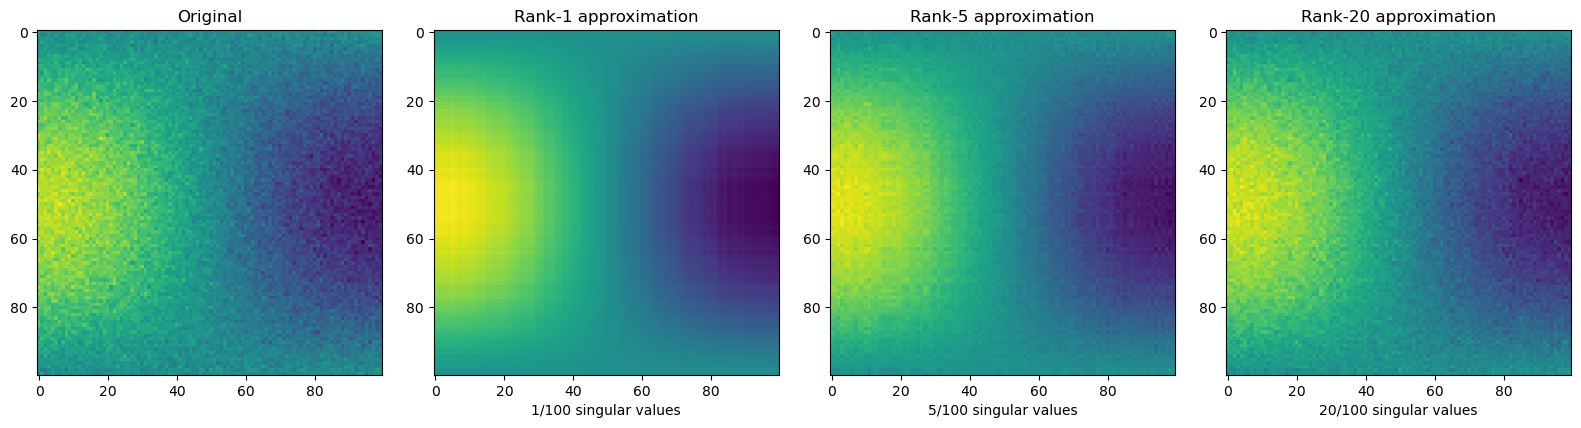

In [167]:
import numpy as np
import matplotlib.pyplot as plt
# Create a 'fake image' matrix for demonstration
np.random.seed(0)
A = np.outer(np.sin(np.linspace(0, np.pi, 100)),
np.cos(np.linspace(0, np.pi, 100)))
A += 0.1 * np.random.randn(100, 100)
U, s, Vt = np.linalg.svd(A)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(A, cmap='viridis'); axes[0].set_title('Original')
for ax, k in zip(axes[1:], [1, 5, 20]):
# Keep only the top-k singular values
    A_approx = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    ax.imshow(A_approx, cmap='viridis')
    ax.set_title(f'Rank-{k} approximation')
    ax.set_xlabel(f'{k}/{len(s)} singular values')
plt.tight_layout()
plt.show()

PC1 explains: 91.4% of variance
PC2 explains: 8.6% of variance


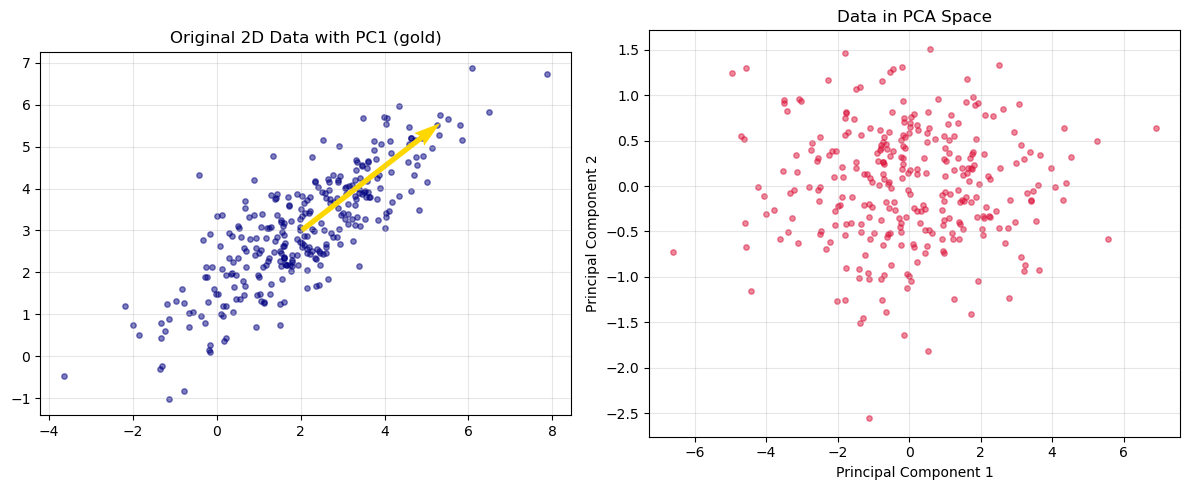

In [168]:
import numpy as np
import matplotlib.pyplot as plt
# Step 1: Create 2D data with a clear 'main direction'
np.random.seed(42)
mean = [2, 3]
cov = [[3, 2], [2, 2]] # Covariance defines the shape/tilt
X = np.random.multivariate_normal(mean, cov, 300) # 300 points, 2D
# Step 2: Center the data (subtract mean)
X_centered = X - X.mean(axis=0)
# Step 3: Compute SVD on the centered data
U, s, Vt = np.linalg.svd(X_centered, full_matrices=False)
# Step 4: Principal components are the rows of Vt
PC1 = Vt[0] # Direction of most variance
PC2 = Vt[1] # Direction of second most variance (perpendicular to PC1)
# Step 5: Project data onto principal components
X_pca = X_centered @ Vt.T # shape (300, 2)
# Visualise
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(X[:,0], X[:,1], alpha=0.5, color='navy', s=15)
# Draw principal component directions
scale = s[0] / np.sqrt(len(X)) * 2
ax1.quiver(*X.mean(axis=0), *PC1*scale, color='gold', scale=1,
scale_units='xy', angles='xy', width=0.01)
ax1.set_title('Original 2D Data with PC1 (gold)')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax2.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5, color='crimson', s=15)
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.set_title('Data in PCA Space')
ax2.grid(True, alpha=0.3)
# Explained variance
explained_var = s**2 / np.sum(s**2)
print(f'PC1 explains: {explained_var[0]*100:.1f}% of variance')
print(f'PC2 explains: {explained_var[1]*100:.1f}% of variance')
plt.tight_layout()
plt.show()

In [172]:
import numpy as np
import matplotlib.pyplot as plt
# Example: f(x, y) = x² + y² (a bowl shape — paraboloid)
# Gradient: ∇f = [df/dx, df/dy] = [2x, 2y]
def f(x, y):
    return x**2 + y**2
def gradient_f(x, y):
    return np.array([2*x, 2*y]) # Analytical gradient
# Numerical gradient approximation (how autograd works conceptually)
def numerical_gradient(f, x, y, h=1e-5):
    df_dx = (f(x+h, y) - f(x-h, y)) / (2*h) # Central difference
    df_dy = (f(x, y+h) - f(x, y-h)) / (2*h)
    return np.array([df_dx, df_dy])
# Test at point (1, 2)
print('Analytical gradient at (1,2):', gradient_f(1, 2))
# [2. 4.]
print('Numerical gradient at (1,2):', numerical_gradient(f, 1, 2))
# [2. 4.] — same! 

Analytical gradient at (1,2): [2 4]
Numerical gradient at (1,2): [2. 4.]


Step 1: x=-1.0000, f(x)=16.000000
Step 2: x=-0.2000, f(x)=10.240000
Step 3: x=0.4400, f(x)=6.553600
Step 4: x=0.9520, f(x)=4.194304
Step 5: x=1.3616, f(x)=2.684355


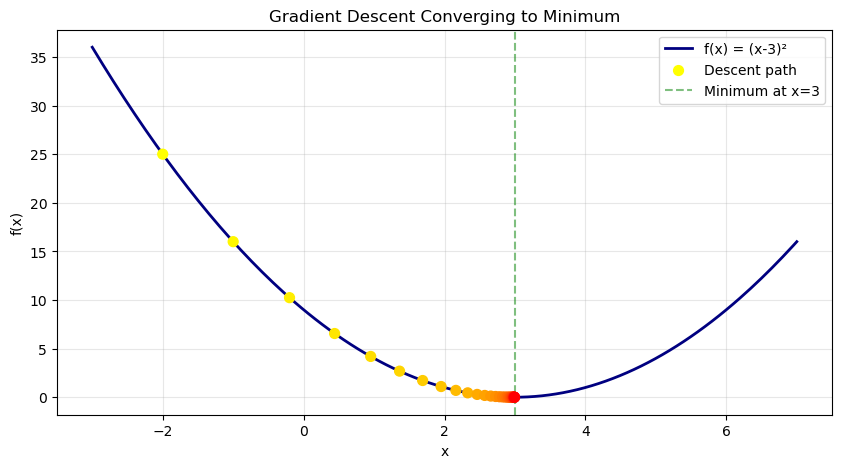

In [188]:
import numpy as np
import matplotlib.pyplot as plt
# Minimise f(x) = (x - 3)^2 (minimum at x = 3)
def f(x): 
    return (x - 3)**2
def df(x): 
    return 2 * (x - 3) # Derivative: df/dx
# Gradient descent loop
x = -2.0 # Starting point (far from minimum)
lr = 0.1 # Learning rate
history = [x] # Record the path
for step in range(30):
    grad = df(x) # Compute gradient
    x = x - lr * grad # Move OPPOSITE to gradient (downhill)
    history.append(x)
    if step < 5: # Print first few steps
        print(f'Step {step+1}: x={x:.4f}, f(x)={f(x):.6f}')
# Visualise the descent
x_range = np.linspace(-3, 7, 200)
plt.figure(figsize=(10, 5))
plt.plot(x_range, f(x_range), 'navy', lw=2, label='f(x) = (x-3)²')
plt.scatter(history, [f(xi) for xi in history],
c=range(len(history)), cmap='autumn_r',
s=50, zorder=5, label='Descent path')
plt.axvline(3, color='green', ls='--', alpha=0.5, label='Minimum at x=3')
plt.xlabel('x'); plt.ylabel('f(x)')
plt.title('Gradient Descent Converging to Minimum')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

In [190]:
import numpy as np
import matplotlib.pyplot as plt
# ── Setup ─────────────────────────────────────────────────────────
np.random.seed(42)
# Simulated dataset: 100 samples, 4 input features each
batch_size = 100
input_dim = 4
output_dim = 3 # This layer has 3 neurons
X = np.random.randn(batch_size, input_dim) # shape: (100, 4)
# ── Layer Parameters ──────────────────────────────────────────────
# He initialization (good for ReLU): scale by sqrt(2/input_dim)
W = np.random.randn(input_dim, output_dim) * np.sqrt(2.0 / input_dim)
b = np.zeros((1, output_dim)) # shape: (1, 3) — broadcasts over batch
print('X shape:', X.shape) # (100, 4)
print('W shape:', W.shape) # (4, 3)
print('b shape:', b.shape) # (1, 3)
# ── Linear Step ───────────────────────────────────────────────────Z = X @ W + b # shape: (100, 3)
# X @ W: (100,4) @ (4,3) = (100,3) — each sample gets 3 outputs
# + b: broadcasts (1,3) across 100 rows
print('Z shape:', Z.shape) # (100, 3)
# ── Activation: ReLU ──────────────────────────────────────────────
# ReLU: f(x) = max(0, x) — kills negative values
A = np.maximum(0, Z) # element-wise max with 0
print('A shape:', A.shape) # (100, 3)

X shape: (100, 4)
W shape: (4, 3)
b shape: (1, 3)
Z shape: (20, 20)
A shape: (20, 20)


In [194]:
import numpy as np
import matplotlib.pyplot as plt
# ── Setup ─────────────────────────────────────────────────────────
np.random.seed(42)
# Simulated dataset: 100 samples, 4 input features each
batch_size = 100
input_dim = 4
output_dim = 3 # This layer has 3 neurons
X = np.random.randn(batch_size, input_dim) # shape: (100, 4)
# ── Layer Parameters ──────────────────────────────────────────────
# He initialization (good for ReLU): scale by sqrt(2/input_dim)
W = np.random.randn(input_dim, output_dim) * np.sqrt(2.0 / input_dim)
b = np.zeros((1, output_dim)) # shape: (1, 3) — broadcasts over batch
print('X shape:', X.shape) # (100, 4)
print('W shape:', W.shape) # (4, 3)
print('b shape:', b.shape) # (1, 3)
# ── Linear Step ───────────────────────────────────────────────────
Z = X @ W + b # shape: (100, 3)
# X @ W: (100,4) @ (4,3) = (100,3) — each sample gets 3 outputs
# + b: broadcasts (1,3) across 100 rows
print('Z shape:', Z.shape) # (100, 3)
# ── Activation: ReLU ──────────────────────────────────────────────
# ReLU: f(x) = max(0, x) — kills negative values
A = np.maximum(0, Z) # element-wise max with 0
print('A shape:', A.shape) # (100, 3)


import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-4, 4, 300)
# Define common activations
relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
leaky = np.where(x > 0, x, 0.1 * x)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
configs = [
(relu, 'ReLU: max(0, x)', 'navy', 'Most common in hidden
layers'),
(sigmoid, 'Sigmoid: 1/(1+e^-x)', 'crimson','Output layer for binary
classification'),
(tanh, 'Tanh: (e^x - e^-x)/(e^x + e^-x)', 'green', 'RNNs — zero-centered'),
(leaky, 'Leaky ReLU: x if x>0 else 0.1x', 'purple','Avoids dying ReLU
problem'),
]
for ax, (y, name, color, note) in zip(axes.flat, configs):
ax.plot(x, y, color=color, lw=2.5)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_title(name, fontsize=12, fontweight='bold')
ax.set_xlabel(note, fontsize=9, color='gray')
ax.grid(True, alpha=0.3)
ax.set_ylim(-1.5, 1.5)
plt.tight_layout()
plt.show()


 # Continuing from the forward pass above...
# Simulated: suppose we have targets and compute a simple MSE loss
y_true = np.random.randn(batch_size, output_dim) # shape (100, 3)
# Loss: Mean Squared Error = mean((A - y_true)^2)
loss = np.mean((A - y_true)**2)
print(f'Loss: {loss:.4f}')
# ── Backward Pass ─────────────────────────────────────────────────
# Step 1: Gradient of loss w.r.t. A
dL_dA = 2 * (A - y_true) / (batch_size * output_dim) # shape (100, 3)
# Step 2: Gradient through ReLU
# ReLU gradient: 1 where Z > 0, else 0
dL_dZ = dL_dA * (Z > 0) # element-wise mask shape (100, 3)
# Step 3: Gradient w.r.t. W
# Z = X @ W, so dZ/dW involves X
# dL/dW = X^T @ dL_dZ
dL_dW = X.T @ dL_dZ # (4, 100) @ (100, 3) = (4, 3) — same shape as W!
# Step 4: Gradient w.r.t. b
# dL/db = sum over batch dimension
dL_db = np.sum(dL_dZ, axis=0, keepdims=True) # (1, 3) — same shape as b!
print('dL/dW shape:', dL_dW.shape) # (4, 3) ✓
print('dL/db shape:', dL_db.shape) # (1, 3) ✓
# ── Weight Update (Gradient Descent) ──────────────────────────────
lr = 0.01
W = W - lr * dL_dW
b = b - lr * dL_db
print('Weights updated!')
6.5 Full Training Loop
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)
# ── Dataset: Learn the function y = sin(x) ──────────────────────
X = np.linspace(-np.pi, np.pi, 200).reshape(-1, 1) # (200, 1)
y = np.sin(X) # (200, 1)
# ── Network: 1 input → 32 hidden → 1 output ─────────────────────
W1 = np.random.randn(1, 32) * 0.5
b1 = np.zeros((1, 32))
W2 = np.random.randn(32, 1) * 0.5
b2 = np.zeros((1, 1))
lr = 0.005
losses = []
for epoch in range(3000):
# Forward
Z1 = X @ W1 + b1 # (200, 32)
A1 = np.tanh(Z1) # tanh activation
Z2 = A1 @ W2 + b2 # (200, 1)
A2 = Z2 # Linear output
loss = np.mean((A2 - y)**2)
losses.append(loss)
# Backward
dL_dA2 = 2 * (A2 - y) / len(X)
dL_dW2 = A1.T @ dL_dA2
dL_db2 = np.sum(dL_dA2, axis=0, keepdims=True)
dL_dA1 = dL_dA2 @ W2.T
dL_dZ1 = dL_dA1 * (1 - np.tanh(Z1)**2) # tanh gradient
dL_dW1 = X.T @ dL_dZ1
dL_db1 = np.sum(dL_dZ1, axis=0, keepdims=True)
# Update
W1 -= lr * dL_dW1; b1 -= lr * dL_db1
W2 -= lr * dL_dW2; b2 -= lr * dL_db2
# ── Visualise Results ────────────────────────────────────────────
Z1_final = X @ W1 + b1
A1_final = np.tanh(Z1_final)
y_pred = A1_final @ W2 + b2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.semilogy(losses, color='navy', lw=1.5)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE Loss (log scale)')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)
ax2.plot(X, y, 'navy', lw=2, label='True: sin(x)')
ax2.plot(X, y_pred, 'gold', lw=2, ls='--', label='Network prediction')
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.set_title('Network Learning sin(x)')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Final loss: {losses[-1]:.6f}')

SyntaxError: unterminated string literal (detected at line 11) (2148974754.py, line 11)